In [1]:
from pymatgen.core.structure import Structure
from sumo.plotting.phonon_bs_plotter import SPhononBSPlotter
from pymatgen.phonon.plotter import PhononDosPlotter
from pymatgen.io.phonopy import get_phonon_dos_from_fc, get_phonon_band_structure_symm_line_from_fc
from sumo.phonon import phonopy as ph
import matplotlib.pyplot as plt
from pymatgen.core.periodic_table import Element
import numpy as np

%config InlineBackend.figure_format = 'retina'

In [5]:
stru = Structure.from_file('/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/phonon/split_01_gen_1/split_01_gen_1.cif')
dim =  [[4,0,0],
        [0,2,0],
        [0,0,2]]
force_constants = ph.load_phonopy('/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/phonon/split_01_gen_1/FORCE_SETS',structure=stru,dim=dim).get_force_constants()

/tmp/ipykernel_482500/3222404723.py:5: DeprecationWarning: Phonopy.get_force_constants() is deprecated.Use Phonopy.force_constants attribute.
  force_constants = ph.load_phonopy('/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/phonon/split_01_gen_1/FORCE_SETS',structure=stru,dim=dim).get_force_constants()


In [9]:
# for i in list1: 
#     pass

s_list = []
Complete_dos_list = []
# for i in list1:
s = Structure.from_file('/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/try/POSCAR') # POSCAR-unitcell 
s_list.append(s)
dim1 =  [[2,0,0],[0,2,0],[0,0,2]]
phonon1 = ph.load_phonopy('/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/try/FORCE_CONSTANTS',structure=s,dim=dim1)
a_fc =get_phonon_dos_from_fc(s,dim1,phonon1.get_force_constants())
Complete_dos_list = []
Complete_dos_list.append(a_fc)

ERROR:root:
Number of atoms in supercell is not consistent with the matrix shape of
force constants read from /lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/try/FORCE_CONSTANTS.
Pleasecarefully check --dim.


SystemExit: 

In [10]:
# for i in list1: 
#     pass
phonon1 = ph.load_phonopy('/lustre/home/acct-umjzhh/umjzhh/suchen/projects/phonon/LiGa/phonon/split_01_gen_1/FORCE_SETS',structure=stru,dim=dim)
a_fc =get_phonon_dos_from_fc(stru,dim,phonon1.get_force_constants())
Complete_dos_list = []
Complete_dos_list.append(a_fc)


/tmp/ipykernel_482500/842074104.py:4: DeprecationWarning: Phonopy.get_force_constants() is deprecated.Use Phonopy.force_constants attribute.
  a_fc =get_phonon_dos_from_fc(stru,dim,phonon1.get_force_constants())


In [11]:
bandstructure = get_phonon_band_structure_symm_line_from_fc(structure=stru,supercell_matrix=dim,force_constants=force_constants)

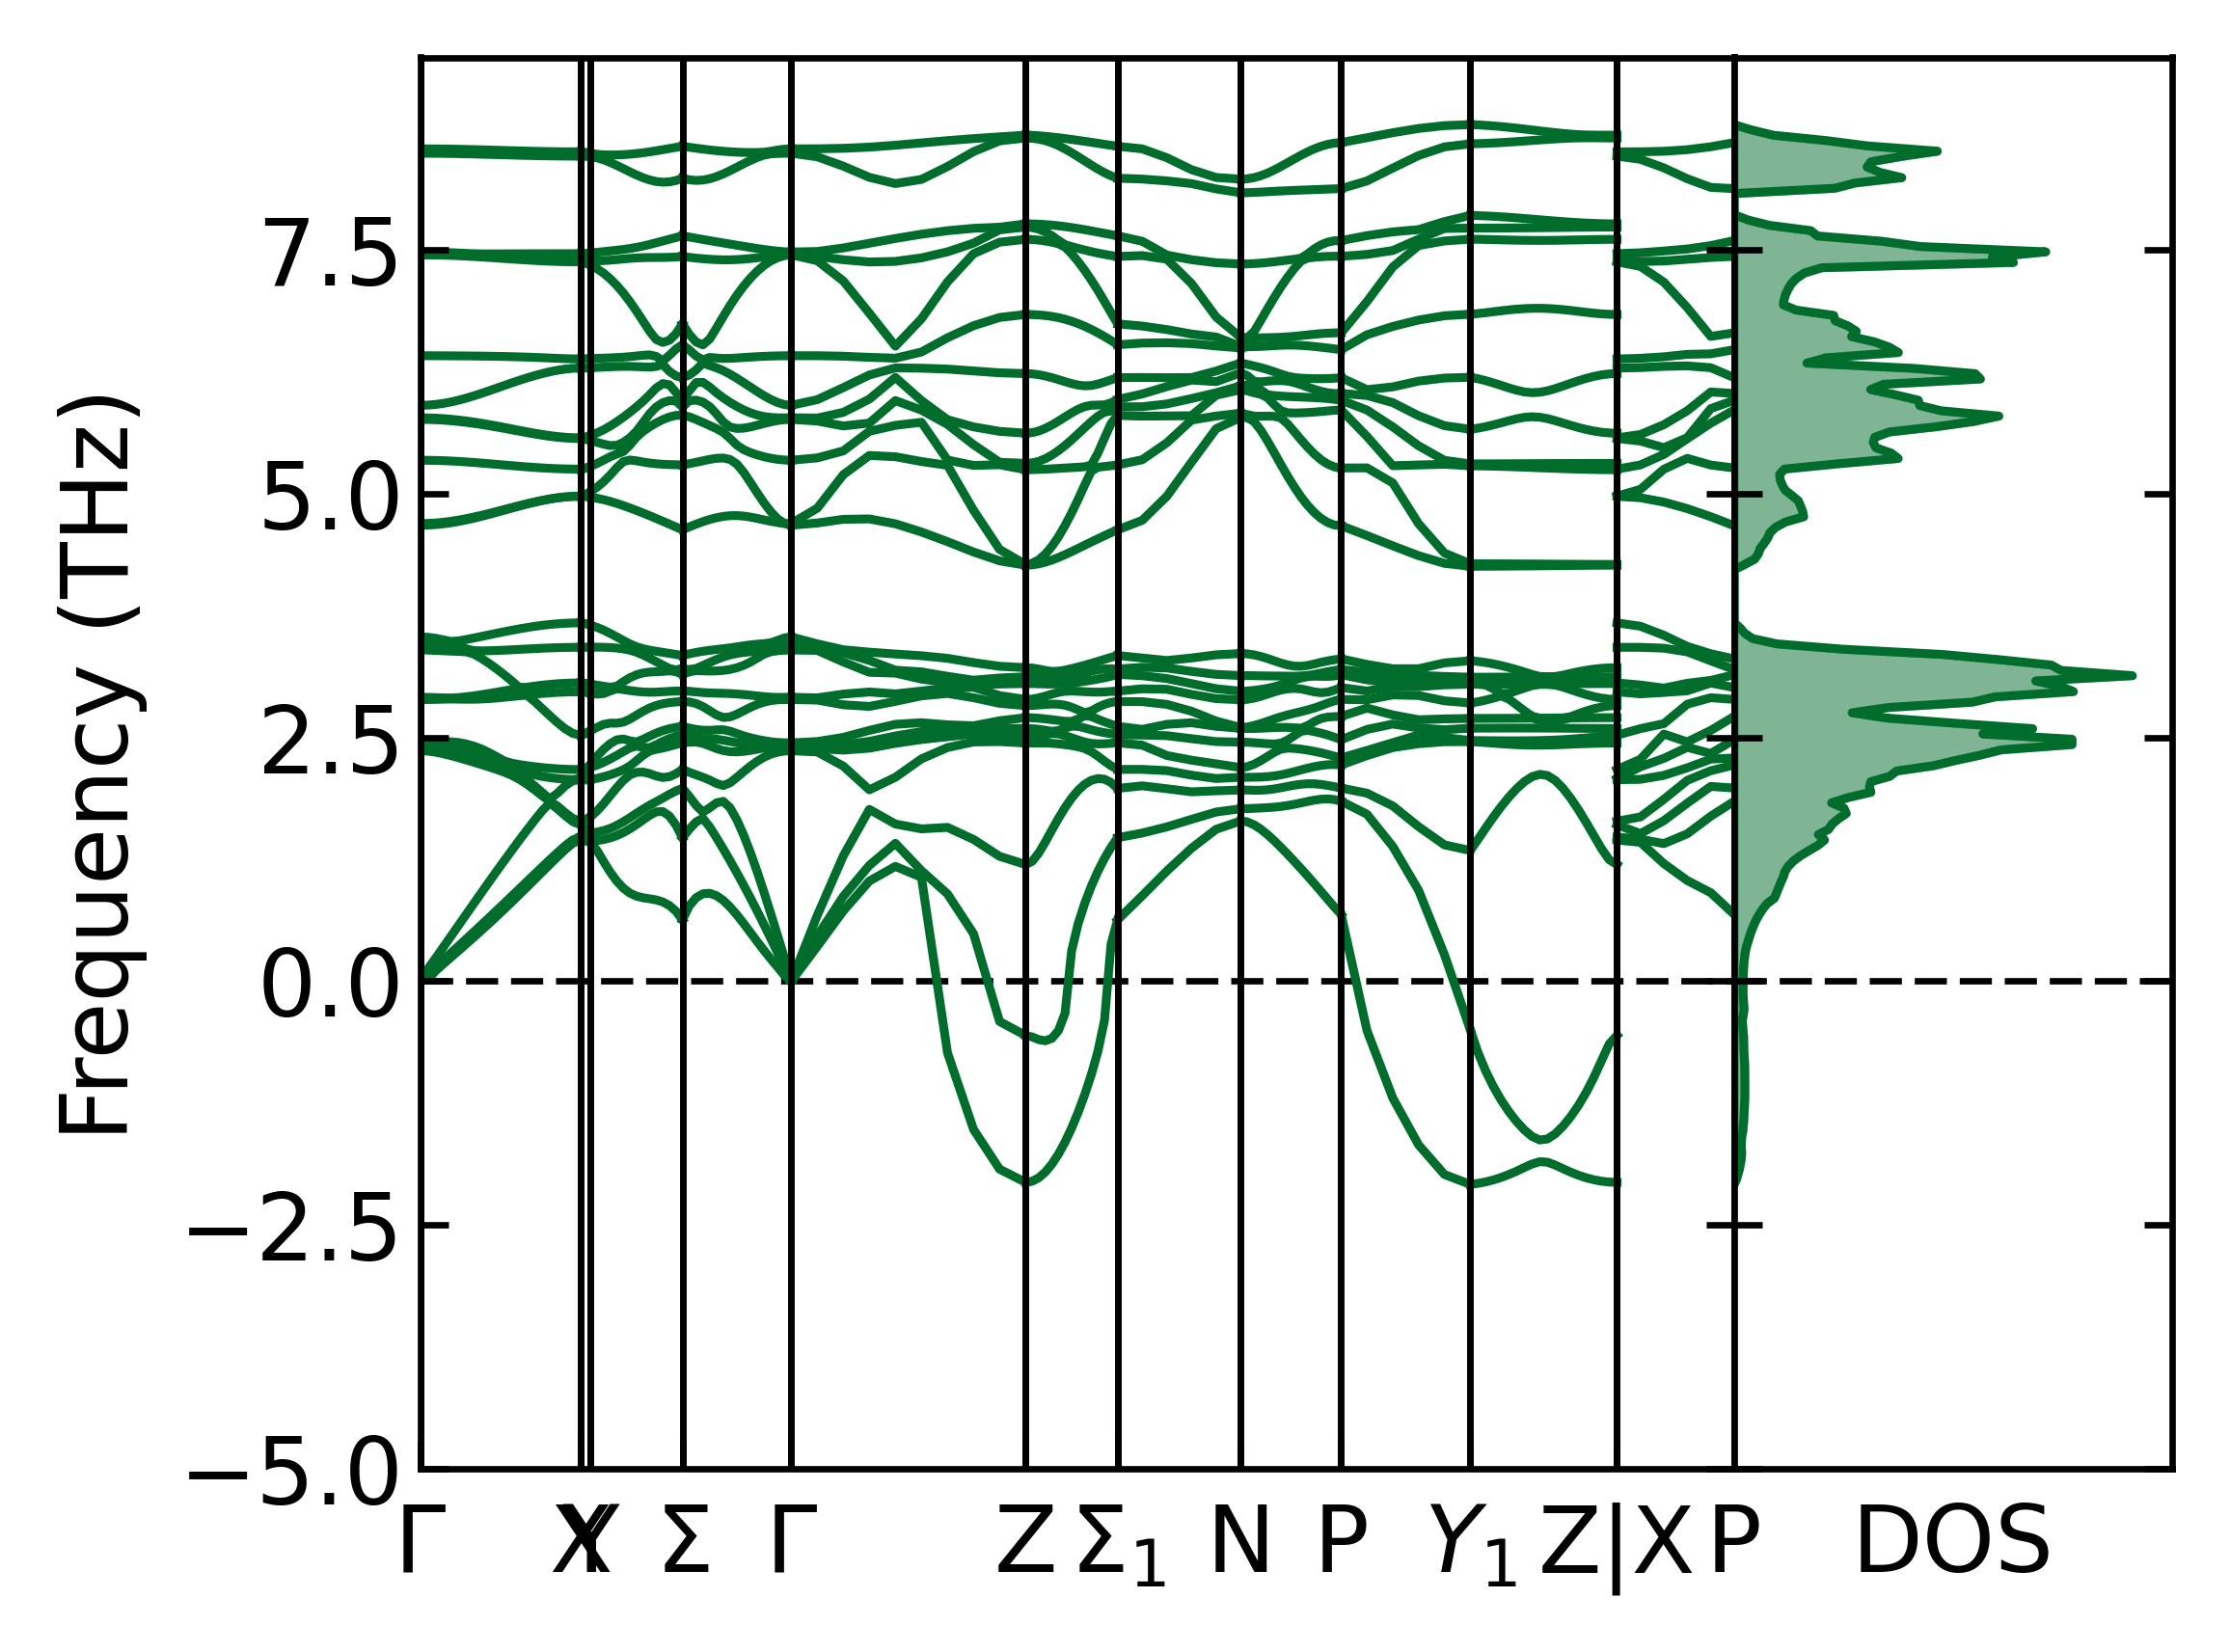

In [12]:
fig = SPhononBSPlotter(bandstructure).get_plot(ymin=-5,width=4,height=3,dpi=300,fonts=['Arial'],dos=np.array([Complete_dos_list[0].frequencies,Complete_dos_list[0].densities]).T)